# نظام إدارة وتشخيص أمراض القلب باستخدام الذكاء الاصطناعي

## Heart Disease Prediction System

### وصف المشروع
يهدف هذا المشروع إلى تطوير نظام ذكي للمساعدة في التنبؤ باحتمالية
الإصابة بأمراض القلب اعتمادًا على مجموعة من البيانات الطبية التي
تتضمن العمر والجنس وألم الصدر وضغط الدم والكوليسترول وغيرها من
المؤشرات الطبية.

سيتم في هذا المشروع:
- استكشاف البيانات وتحليلها.
- تنظيف ومعالجة البيانات المفقودة.
- تحليل العلاقة بين المتغيرات وأمراض القلب.
- تدريب عدة نماذج من نماذج تعلم الآلة.
- مقارنة أداء النماذج.
- اختيار النموذج الأفضل.
- تقييم النموذج باستخدام عدة مقاييس.
- حفظ النموذج لاستخدامه لاحقًا داخل Flask API.

In [121]:
# التعامل مع البيانات
import pandas as pd
import numpy as np

# التصوير وتحليل البيانات
import matplotlib.pyplot as plt
import seaborn as sns

# أدوات تعلم الآلة
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# النماذج
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# تقييم النماذج
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# إخفاء التحذيرات غير الضرورية
import warnings
warnings.filterwarnings("ignore")

# إعدادات الرسومات
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [122]:
# قراءة ملف البيانات
df = pd.read_csv("heart_disease_uci.csv")

# عرض أول خمس سجلات
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [123]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 920
Number of columns: 16


In [124]:
# عرض معلومات عامة عن البيانات
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [125]:
# عرض الإحصاءات الوصفية لجميع الأعمدة
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [126]:
# حساب عدد القيم المفقودة في كل عمود
missing_values = df.isnull().sum()

# حساب نسبة القيم المفقودة من إجمالي السجلات
missing_percentage = (missing_values / len(df)) * 100

# إنشاء جدول يوضح عدد ونسبة القيم المفقودة
missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

# الاحتفاظ بالأعمدة التي تحتوي على قيم مفقودة فقط
missing_df = missing_df[missing_df["Missing Values"] > 0]

# ترتيب الأعمدة حسب نسبة القيم المفقودة
missing_df.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
exang,55,5.978261
thalch,55,5.978261
chol,30,3.260870
restecg,2,0.217391


In [127]:
# عرض القيم الفريدة الموجودة في كل عمود
for column in df.columns:
    
    # عرض اسم العمود
    print(f"\n--- {column} ---")
    
    # عرض القيم الفريدة للعمود
    print(df[column].unique())


--- id ---
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 24

In [128]:
# عرض القيم الموجودة في المتغير الهدف
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

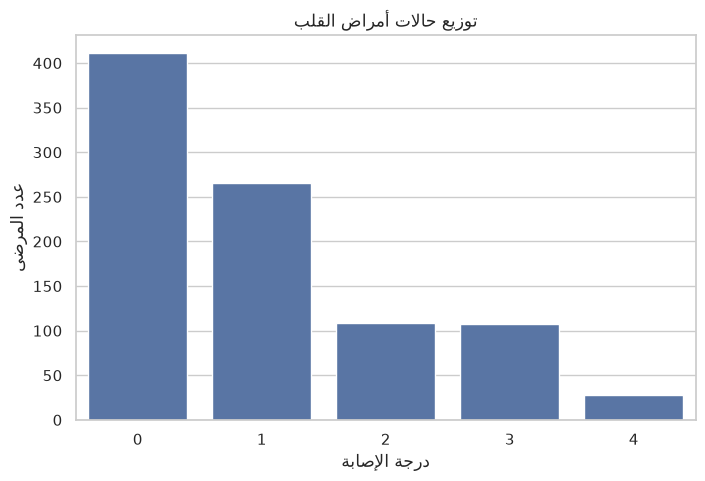

In [129]:
# رسم عدد الحالات لكل قيمة في المتغير الهدف
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="num")

# إضافة عنوان للرسم
plt.title("توزيع حالات أمراض القلب")

# تسمية المحور الأفقي
plt.xlabel("درجة الإصابة")

# تسمية المحور الرأسي
plt.ylabel("عدد المرضى")

# عرض الرسم
plt.show()

In [130]:
# حساب النسبة المئوية لكل قيمة في المتغير الهدف
target_percentage = df["num"].value_counts(normalize=True) * 100

# ترتيب النتائج حسب قيمة المتغير الهدف
target_percentage = target_percentage.sort_index()

# عرض النسب المئوية
target_percentage

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64

In [131]:
# تحديد الأعمدة التي تحتوي على بيانات رقمية
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# عرض أسماء المتغيرات الرقمية
numerical_columns

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='str')

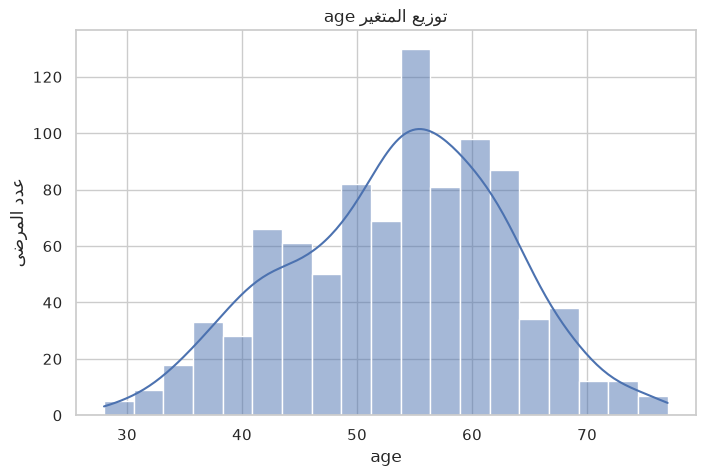

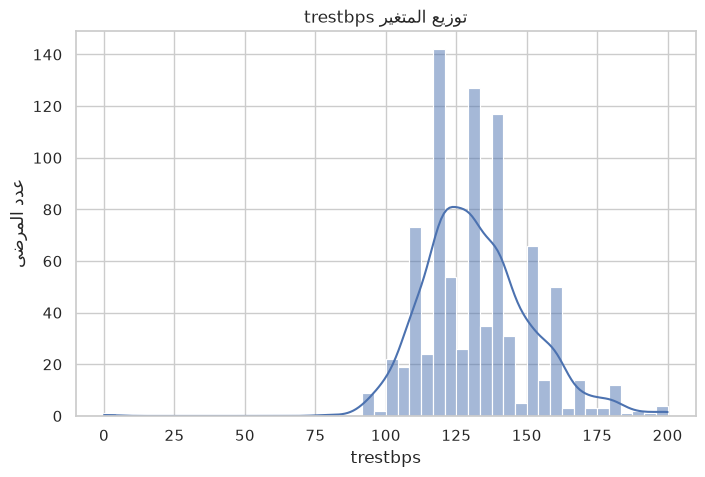

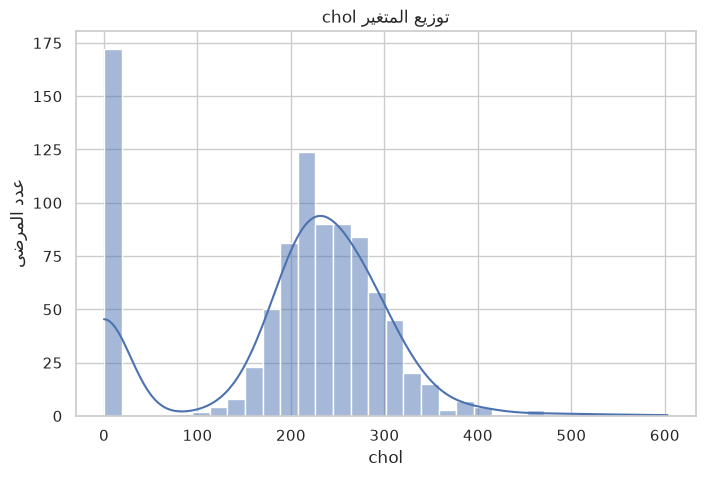

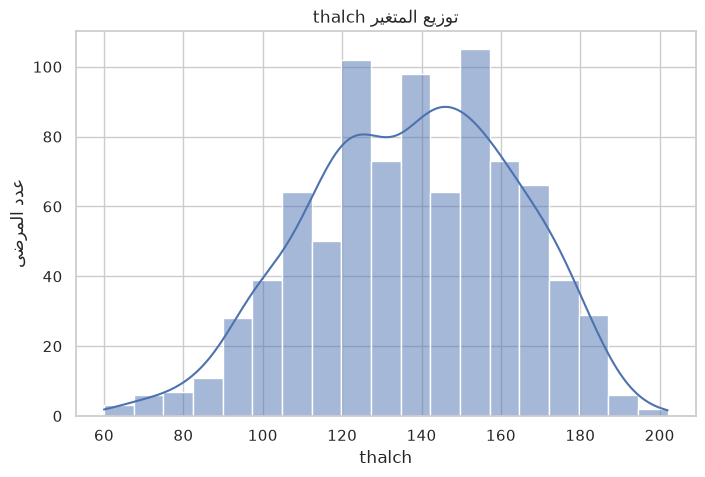

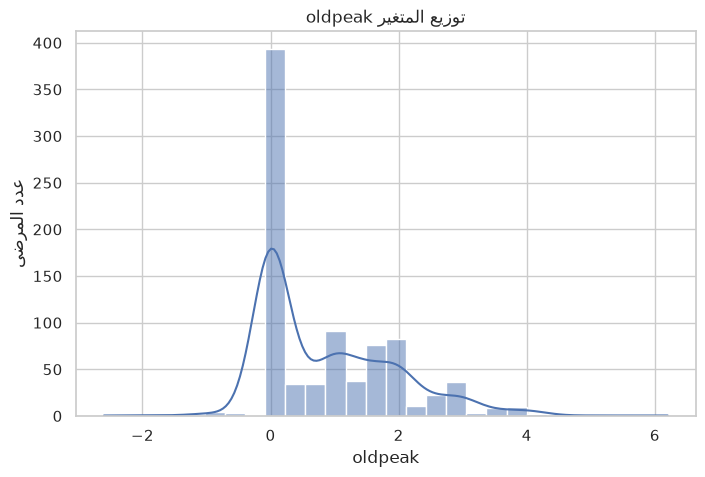

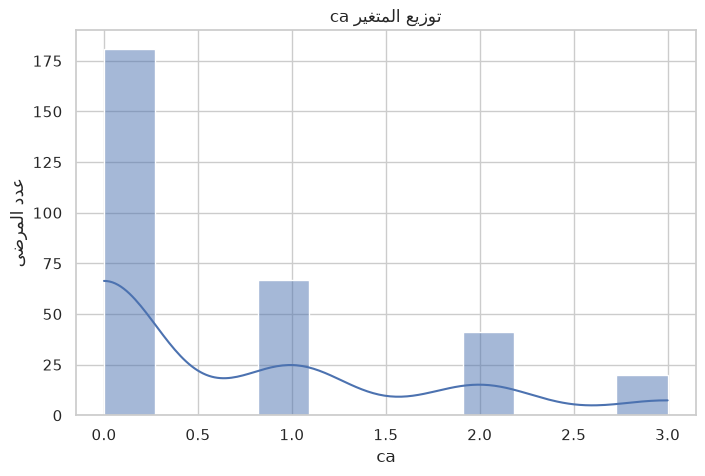

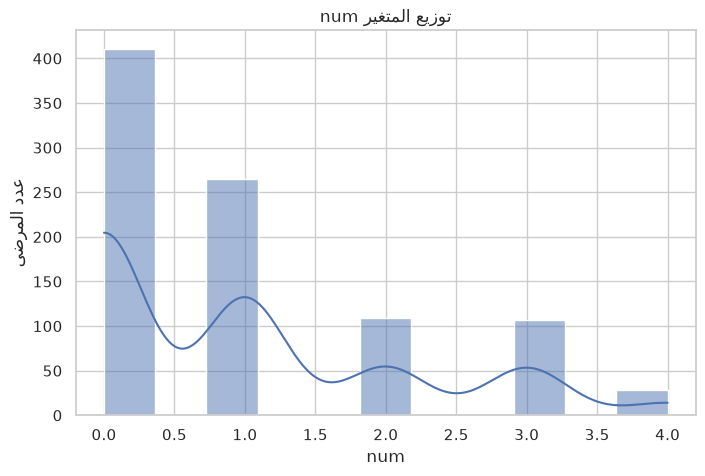

In [132]:
# تحديد الأعمدة الرقمية باستثناء عمود المعرّف
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
numerical_columns = numerical_columns.drop("id", errors="ignore")

# إنشاء رسم لتوزيع كل متغير رقمي
for column in numerical_columns:
    
    # إنشاء رسم جديد لكل متغير
    plt.figure(figsize=(8, 5))
    
    # رسم توزيع القيم مع منحنى التوزيع
    sns.histplot(data=df, x=column, kde=True)
    
    # إضافة عنوان للرسم
    plt.title(f"توزيع المتغير {column}")
    
    # تسمية المحور الأفقي
    plt.xlabel(column)
    
    # تسمية المحور الرأسي
    plt.ylabel("عدد المرضى")
    
    # عرض الرسم
    plt.show()

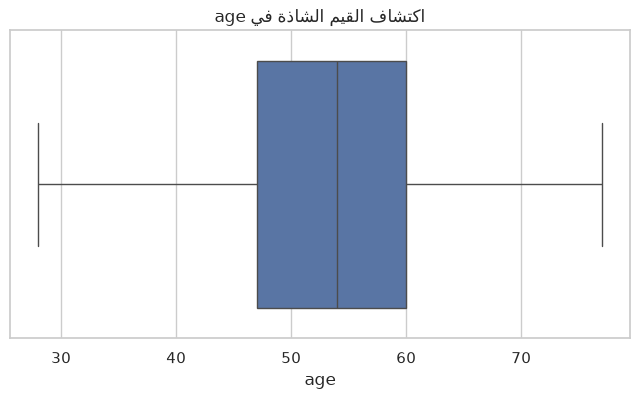

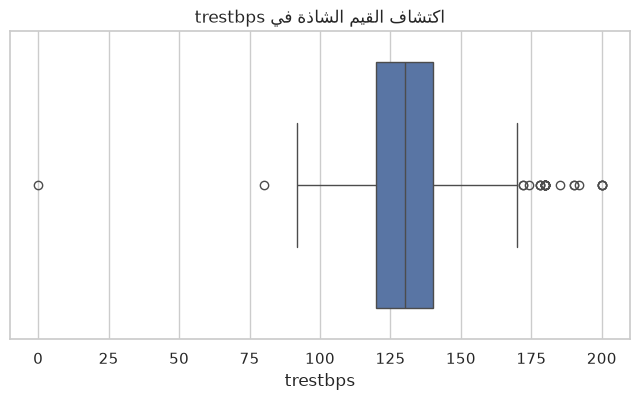

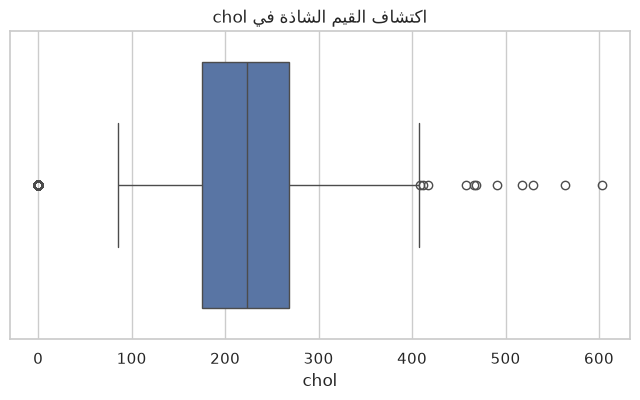

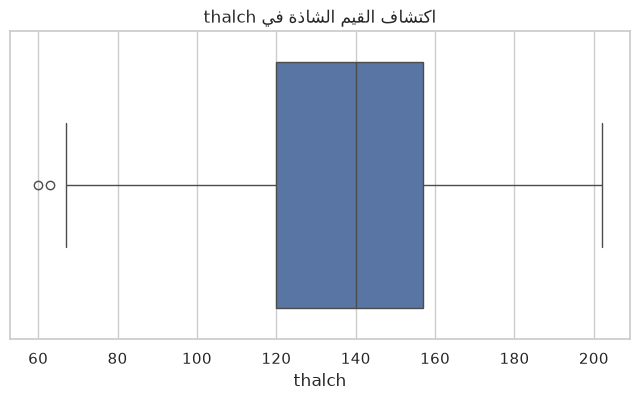

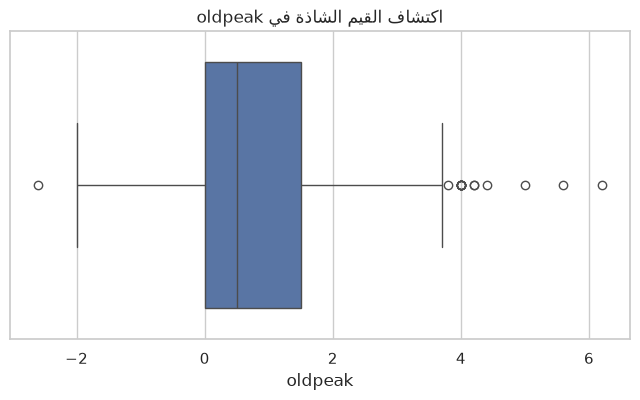

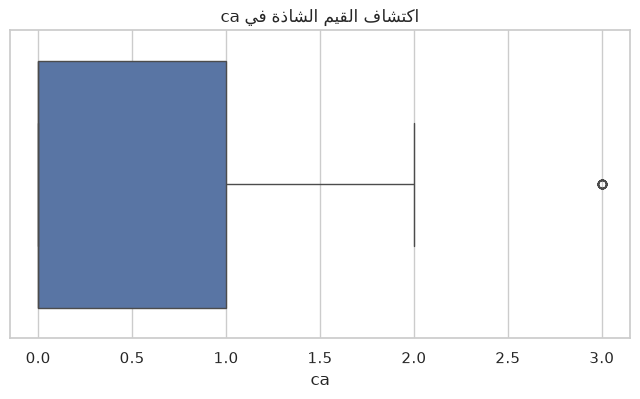

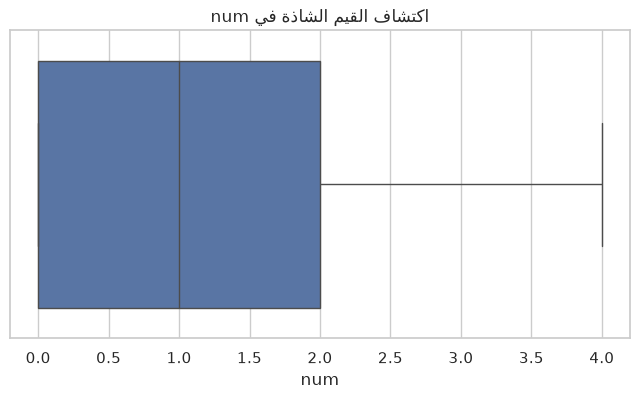

In [133]:
# إنشاء رسوم Boxplot للمتغيرات الرقمية
for column in numerical_columns:
    
    # إنشاء رسم جديد لكل متغير
    plt.figure(figsize=(8, 4))
    
    # رسم Boxplot للمتغير
    sns.boxplot(data=df, x=column)
    
    # إضافة عنوان للرسم
    plt.title(f"اكتشاف القيم الشاذة في {column}")
    
    # تسمية المحور الأفقي
    plt.xlabel(column)
    
    # عرض الرسم
    plt.show()

In [134]:
# تحديد الأعمدة الفئوية في البيانات
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

# عرض أسماء المتغيرات الفئوية
categorical_columns

Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='str')

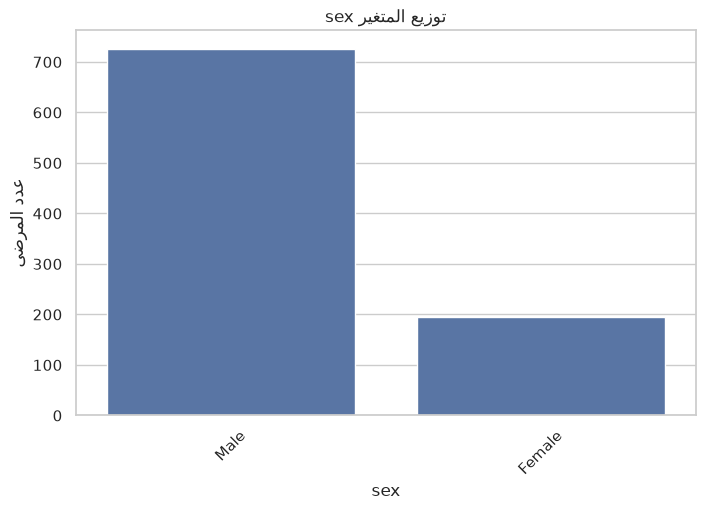

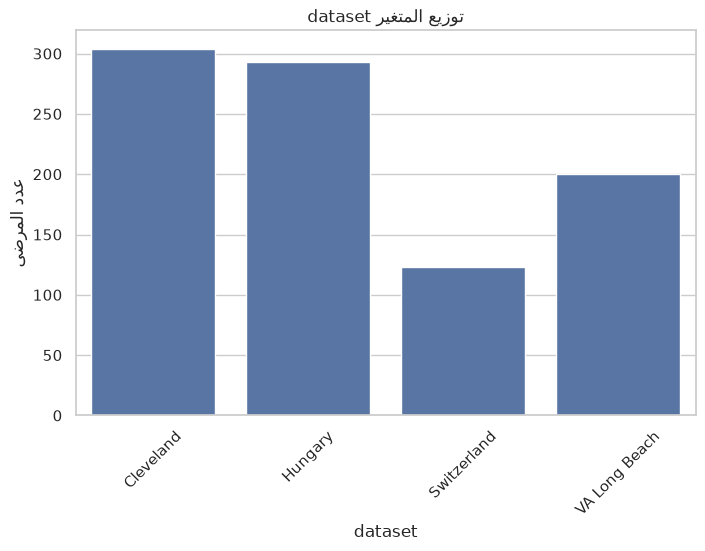

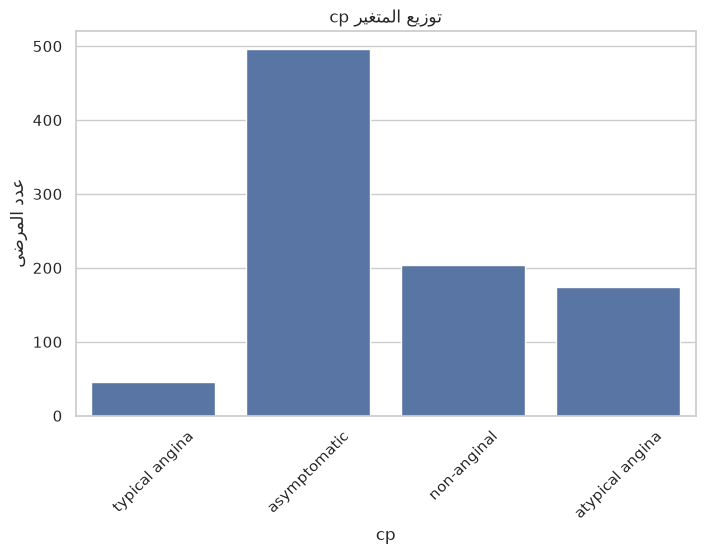

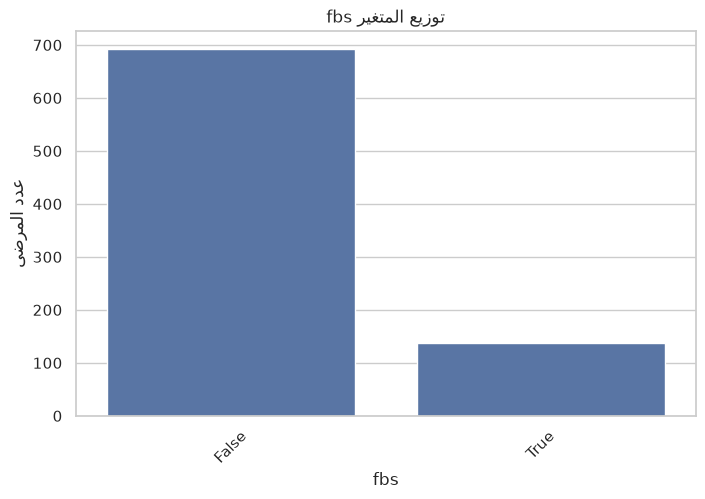

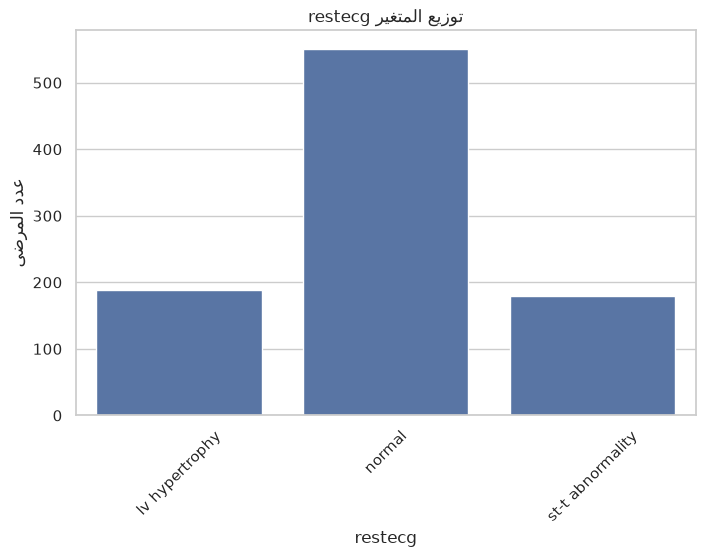

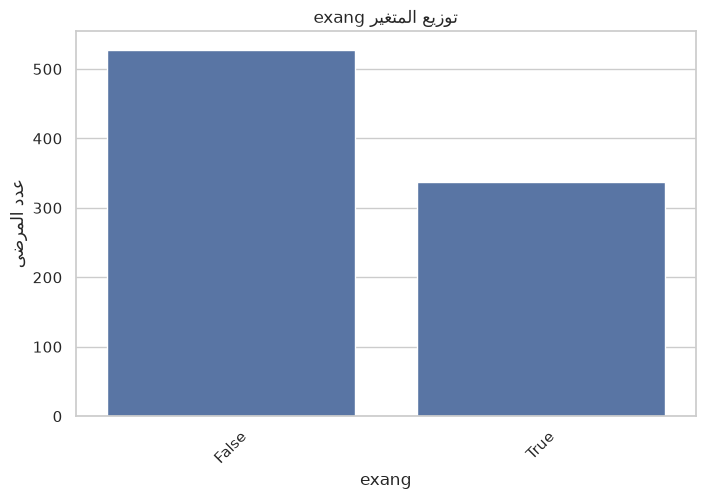

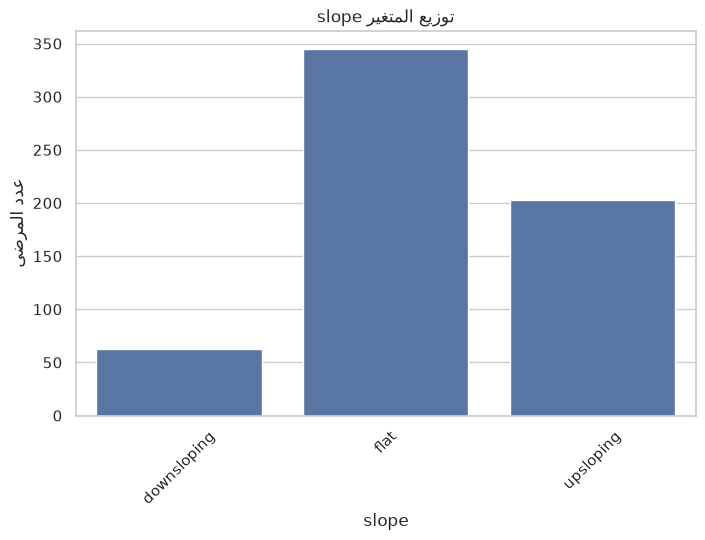

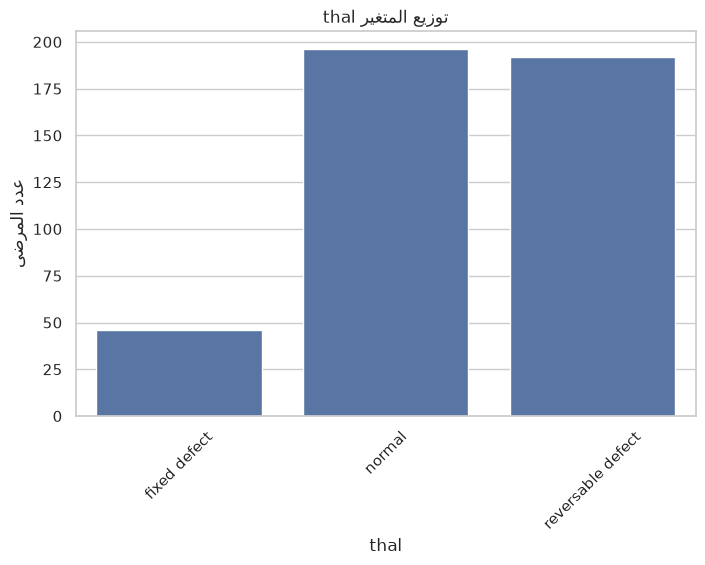

In [135]:
# إنشاء رسم لتوزيع كل متغير فئوي
for column in categorical_columns:
    
    # إنشاء رسم جديد لكل متغير
    plt.figure(figsize=(8, 5))
    
    # رسم عدد المرضى في كل فئة
    sns.countplot(data=df, x=column)
    
    # إضافة عنوان للرسم
    plt.title(f"توزيع المتغير {column}")
    
    # تسمية المحور الأفقي
    plt.xlabel(column)
    
    # تسمية المحور الرأسي
    plt.ylabel("عدد المرضى")
    
    # تدوير أسماء الفئات لتسهيل قراءتها
    plt.xticks(rotation=45)
    
    # عرض الرسم
    plt.show()

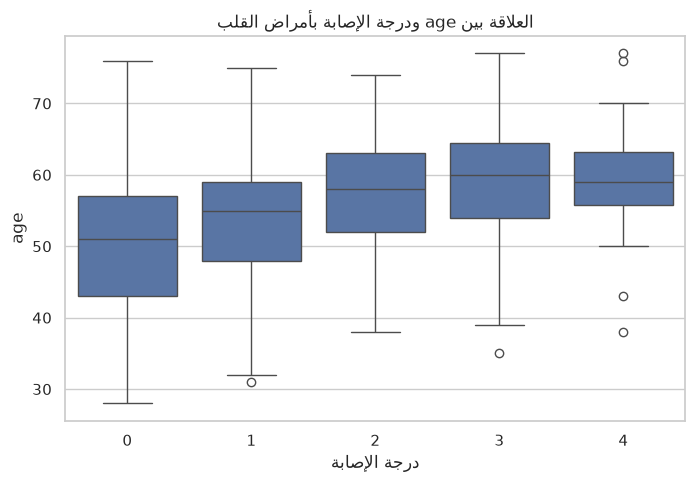

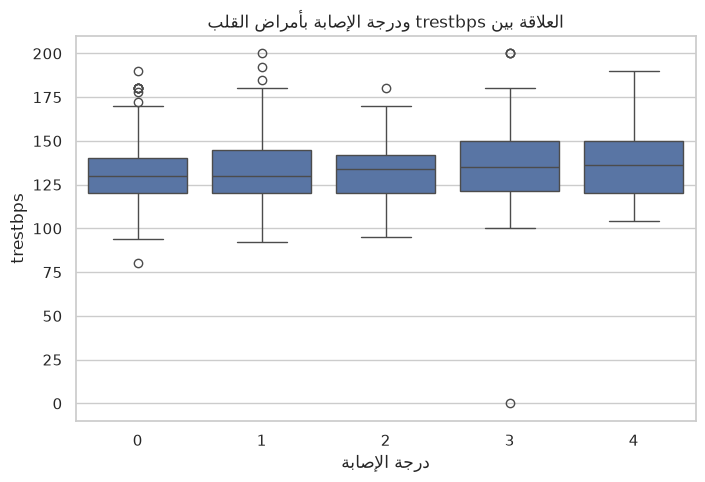

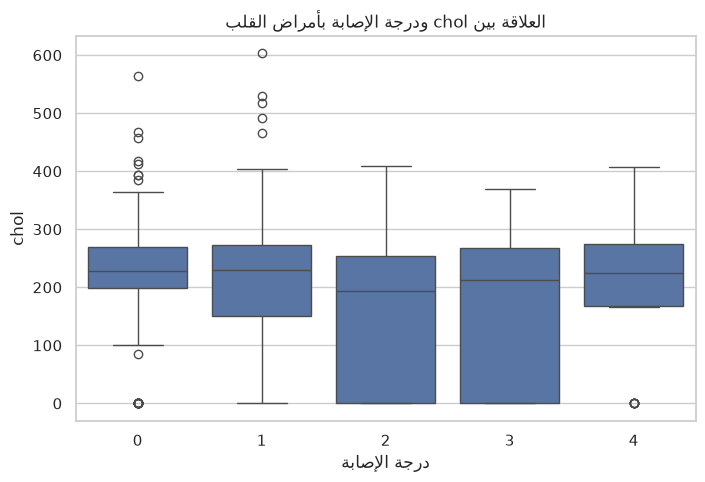

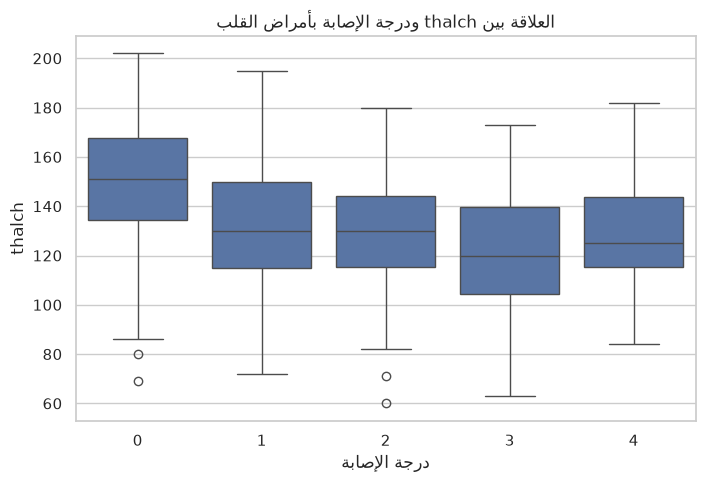

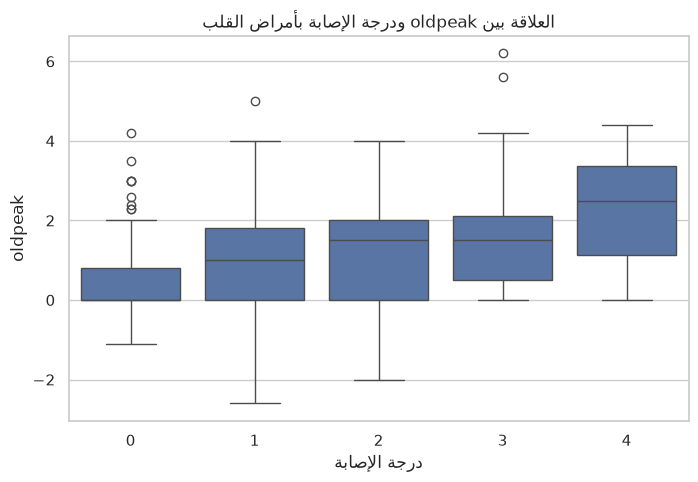

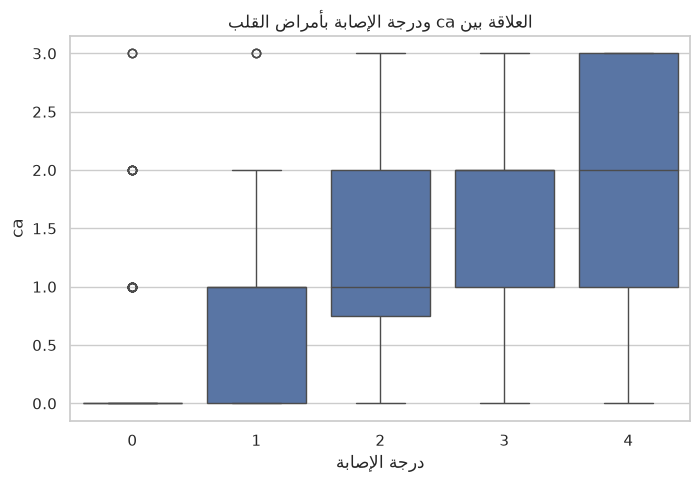

In [136]:
# إنشاء رسم يوضح العلاقة بين كل متغير رقمي والمتغير الهدف
for column in numerical_columns:
    
    # تجاهل المتغير الهدف نفسه
    if column == "num":
        continue
    
    # إنشاء رسم جديد لكل متغير
    plt.figure(figsize=(8, 5))
    
    # رسم Boxplot لمقارنة المتغير مع مستويات الإصابة
    sns.boxplot(data=df, x="num", y=column)
    
    # إضافة عنوان للرسم
    plt.title(f"العلاقة بين {column} ودرجة الإصابة بأمراض القلب")
    
    # تسمية المحور الأفقي
    plt.xlabel("درجة الإصابة")
    
    # تسمية المحور الرأسي
    plt.ylabel(column)
    
    # عرض الرسم
    plt.show()

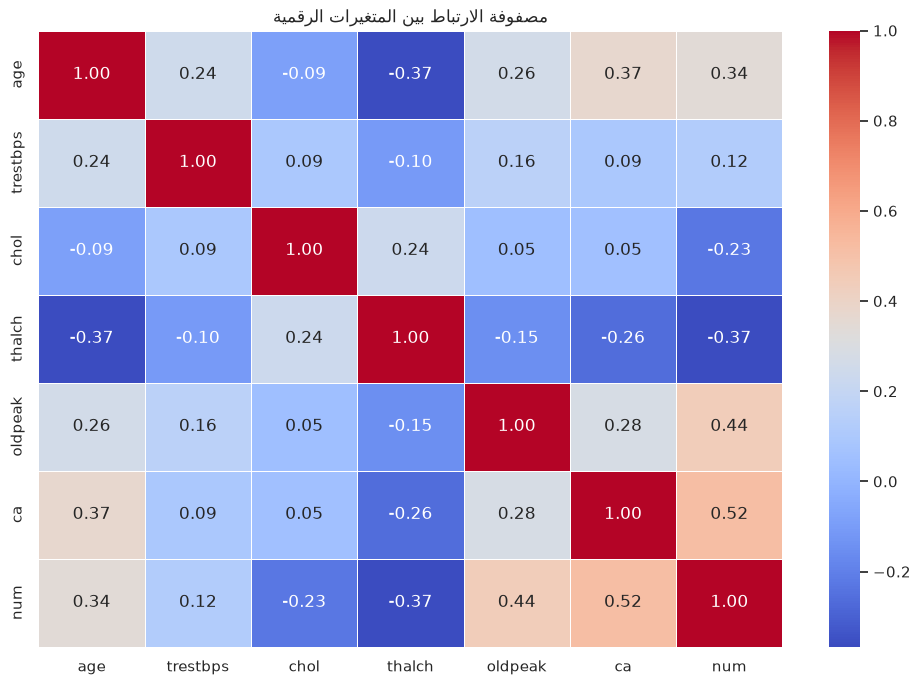

In [137]:
# حساب معاملات الارتباط بين المتغيرات الرقمية
correlation_matrix = df[numerical_columns].corr()

# إنشاء حجم الرسم
plt.figure(figsize=(12, 8))

# رسم مصفوفة الارتباط باستخدام خريطة حرارية
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# إضافة عنوان للرسم
plt.title("مصفوفة الارتباط بين المتغيرات الرقمية")

# عرض الرسم
plt.show()

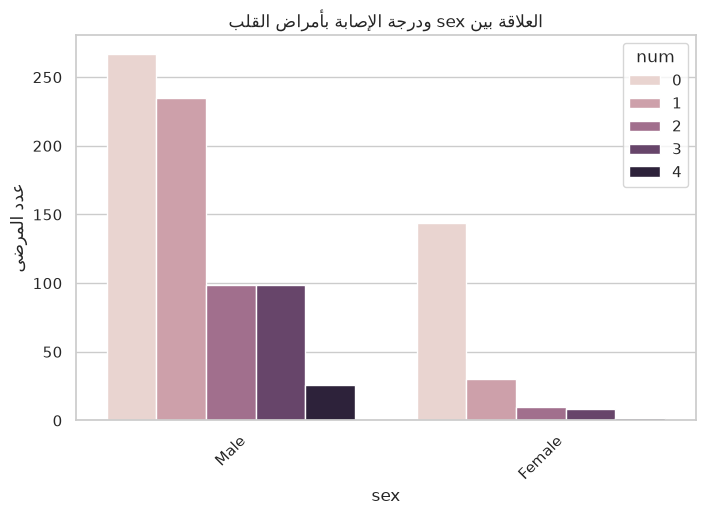

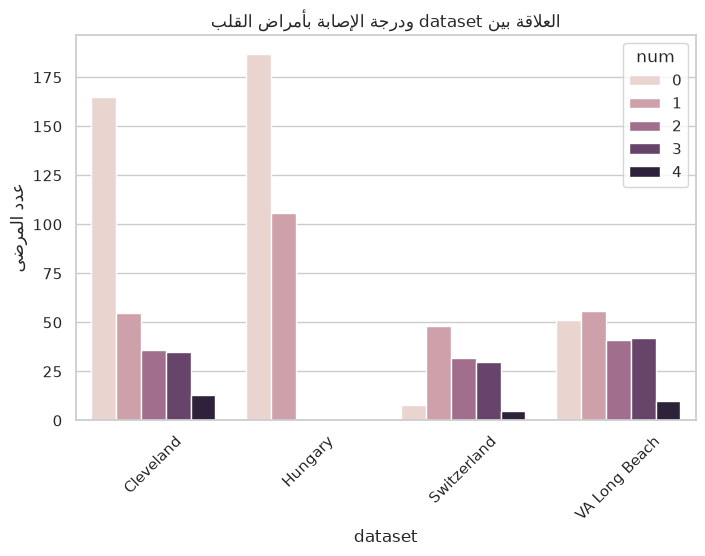

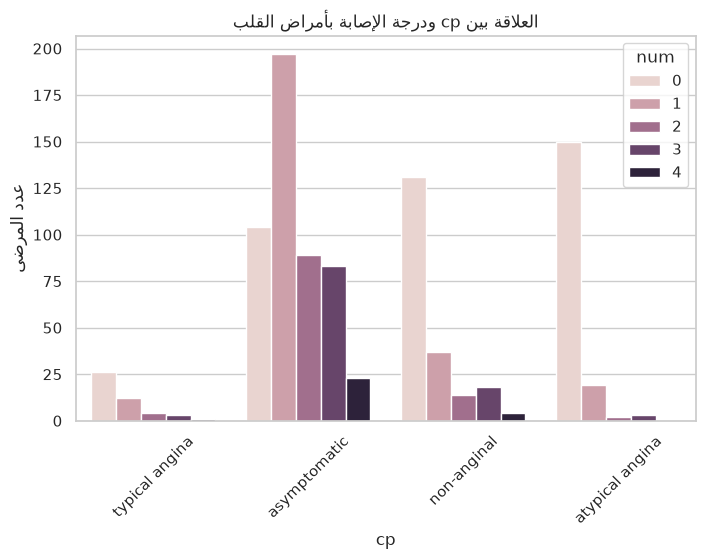

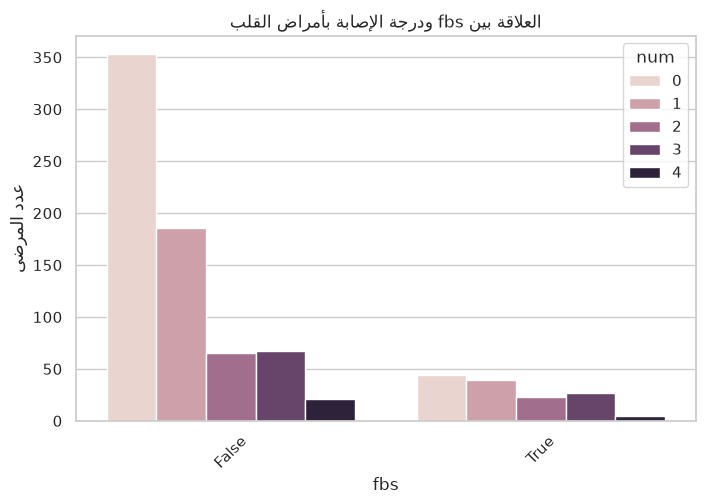

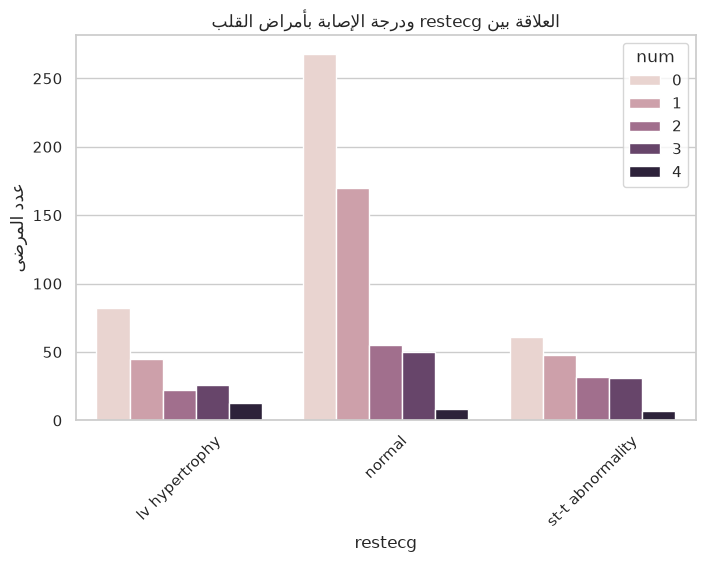

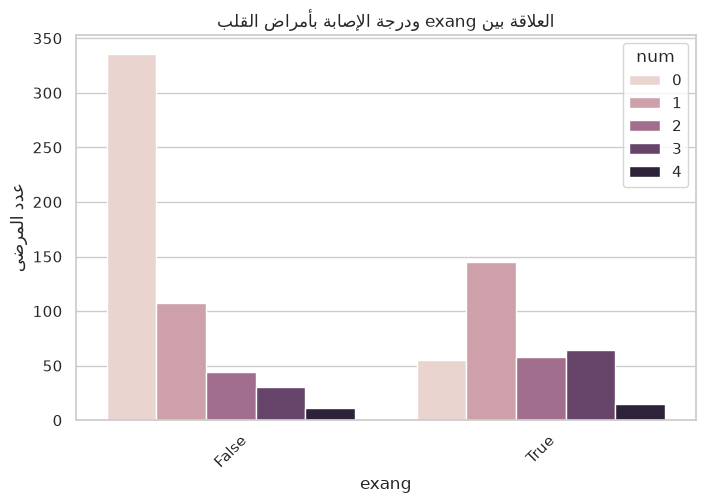

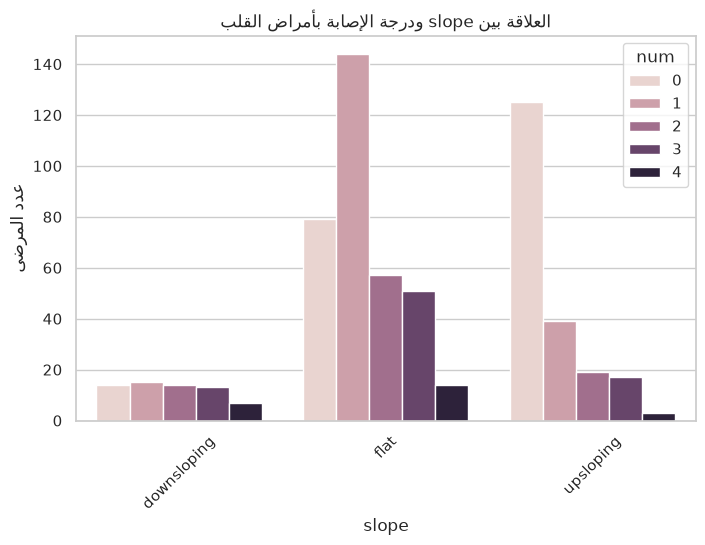

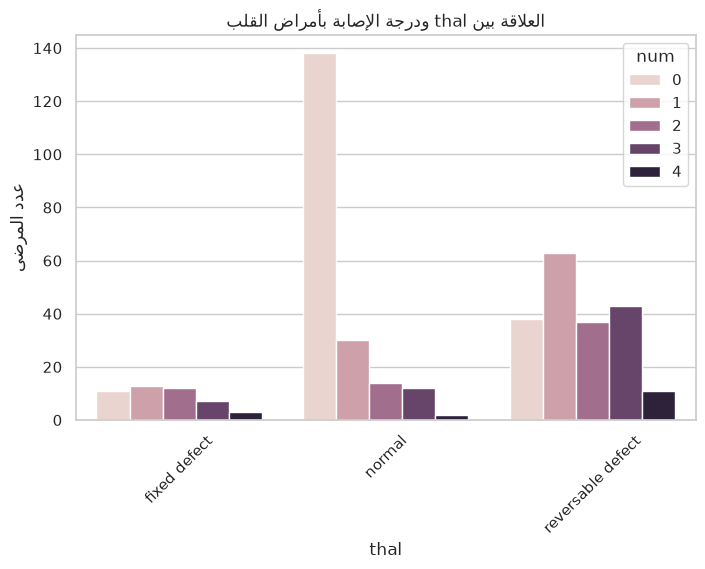

In [138]:
# إنشاء رسم يوضح العلاقة بين كل متغير فئوي والمتغير الهدف
for column in categorical_columns:
    
    # إنشاء رسم جديد لكل متغير
    plt.figure(figsize=(8, 5))
    
    # رسم عدد الحالات لكل فئة مع تقسيمها حسب درجة الإصابة
    sns.countplot(data=df, x=column, hue="num")
    
    # إضافة عنوان للرسم
    plt.title(f"العلاقة بين {column} ودرجة الإصابة بأمراض القلب")
    
    # تسمية المحور الأفقي
    plt.xlabel(column)
    
    # تسمية المحور الرأسي
    plt.ylabel("عدد المرضى")
    
    # تدوير أسماء الفئات لتسهيل قراءتها
    plt.xticks(rotation=45)
    
    # عرض الرسم
    plt.show()

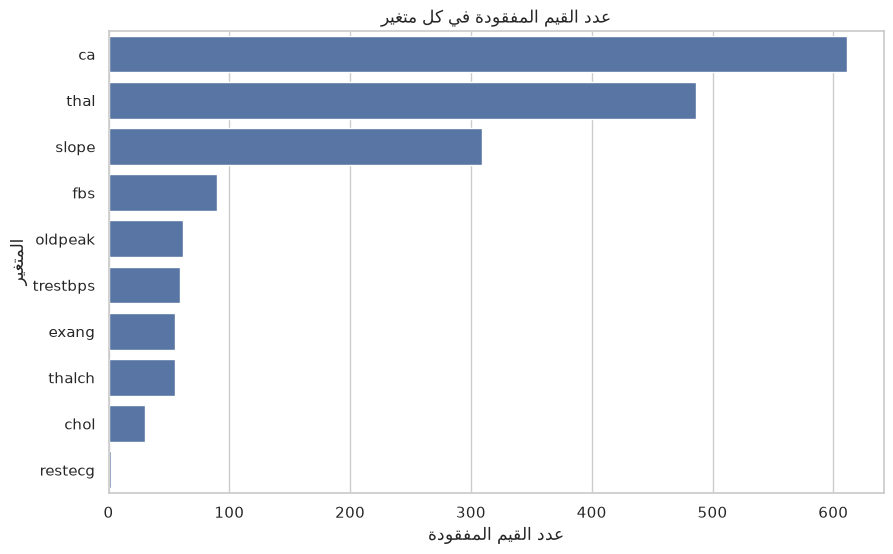

In [139]:
# حساب عدد القيم المفقودة في كل عمود
missing_values = df.isnull().sum()

# الاحتفاظ بالأعمدة التي تحتوي على قيم مفقودة فقط
missing_values = missing_values[missing_values > 0]

# ترتيب الأعمدة تنازليًا حسب عدد القيم المفقودة
missing_values = missing_values.sort_values(ascending=False)

# إنشاء رسم يوضح عدد القيم المفقودة
plt.figure(figsize=(10, 6))

# رسم القيم المفقودة لكل عمود
sns.barplot(
    x=missing_values.values,
    y=missing_values.index
)

# إضافة عنوان للرسم
plt.title("عدد القيم المفقودة في كل متغير")

# تسمية المحور الأفقي
plt.xlabel("عدد القيم المفقودة")

# تسمية المحور الرأسي
plt.ylabel("المتغير")

# عرض الرسم
plt.show()

In [140]:
# تحديد الأعمدة الرقمية التي تحتوي على قيم مفقودة
numerical_missing_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns[df.select_dtypes(
    include=["int64", "float64"]
).isnull().any()]

# معالجة القيم المفقودة في الأعمدة الرقمية باستخدام الوسيط
for column in numerical_missing_columns:
    
    # حساب الوسيط للعمود
    median_value = df[column].median()
    
    # استبدال القيم المفقودة بالوسيط
    df[column] = df[column].fillna(median_value)


# تحديد الأعمدة الفئوية التي تحتوي على قيم مفقودة
categorical_missing_columns = df.select_dtypes(
    include=["object", "category"]
).columns[df.select_dtypes(
    include=["object", "category"]
).isnull().any()]

# معالجة القيم المفقودة في الأعمدة الفئوية باستخدام المنوال
for column in categorical_missing_columns:
    
    # حساب أكثر قيمة تكرارًا في العمود
    mode_value = df[column].mode()[0]
    
    # استبدال القيم المفقودة بالمنوال
    df[column] = df[column].fillna(mode_value)

In [141]:
# حساب عدد القيم المفقودة المتبقية في كل عمود
missing_after = df.isnull().sum()

# عرض الأعمدة التي لا تزال تحتوي على قيم مفقودة
missing_after[missing_after > 0]

Series([], dtype: int64)

In [142]:
# تحويل المتغير الهدف إلى تصنيف ثنائي
# القيمة 0 تعني عدم وجود مرض
# القيم من 1 إلى 4 تعني وجود مرض
df["target"] = (df["num"] > 0).astype(int)

# عرض توزيع الفئات الجديدة
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [143]:
# حساب النسبة المئوية لكل فئة في المتغير الهدف
target_distribution = df["target"].value_counts(normalize=True) * 100

# ترتيب النتائج حسب قيمة المتغير الهدف
target_distribution = target_distribution.sort_index()

# عرض النسب المئوية
target_distribution

target
0    44.673913
1    55.326087
Name: proportion, dtype: float64

In [144]:
# حذف المتغير الأصلي num بعد إنشاء المتغير الهدف الجديد
df = df.drop(columns=["num"])

# فصل المتغيرات المستقلة عن المتغير الهدف
# X تحتوي على الخصائص الطبية المستخدمة في التنبؤ
# y تحتوي على النتيجة التي نريد من النموذج التنبؤ بها
X = df.drop(columns=["target"])
y = df["target"]

# عرض أبعاد بيانات المدخلات
print("حجم بيانات المدخلات:", X.shape)

# عرض أبعاد المتغير الهدف
print("حجم المتغير الهدف:", y.shape)

حجم بيانات المدخلات: (920, 15)
حجم المتغير الهدف: (920,)


In [145]:
# عرض أول خمس سجلات من بيانات المدخلات
X.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [146]:
# عرض أول خمس قيم من المتغير الهدف
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [147]:
# حذف عمود المعرّف لأنه لا يحتوي على معلومات طبية مفيدة للتنبؤ
df = df.drop(columns=["id"], errors="ignore")

# فصل المتغيرات المستقلة عن المتغير الهدف
X = df.drop(columns=["target"])
y = df["target"]

# تقسيم البيانات إلى بيانات تدريب واختبار
# نستخدم 80% للتدريب و20% للاختبار
# stratify يحافظ على نسبة الفئات في مجموعتي التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# التأكد من عدم وجود id في بيانات التدريب
print("هل يوجد id في بيانات التدريب؟", "id" in X_train.columns)

# عرض أسماء الأعمدة المستخدمة في التدريب
print("\nأعمدة التدريب:")
print(X_train.columns.tolist())

هل يوجد id في بيانات التدريب؟ False

أعمدة التدريب:
['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [148]:
# تقسيم البيانات إلى بيانات تدريب وبيانات اختبار
# نستخدم 80% من البيانات للتدريب و20% للاختبار
# stratify يحافظ على توزيع الفئات في مجموعتي التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# عرض حجم بيانات التدريب
print("حجم بيانات التدريب:", X_train.shape)

# عرض حجم بيانات الاختبار
print("حجم بيانات الاختبار:", X_test.shape)

# عرض توزيع الفئات في بيانات التدريب
print("\nتوزيع الفئات في بيانات التدريب:")
print(y_train.value_counts())

# عرض توزيع الفئات في بيانات الاختبار
print("\nتوزيع الفئات في بيانات الاختبار:")
print(y_test.value_counts())

حجم بيانات التدريب: (736, 14)
حجم بيانات الاختبار: (184, 14)

توزيع الفئات في بيانات التدريب:
target
1    407
0    329
Name: count, dtype: int64

توزيع الفئات في بيانات الاختبار:
target
1    102
0     82
Name: count, dtype: int64


In [149]:
# تحديد الأعمدة الرقمية في بيانات التدريب
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# تحديد الأعمدة الفئوية في بيانات التدريب
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

# عرض الأعمدة الرقمية
print("الأعمدة الرقمية:")
print(list(numerical_features))

# عرض الأعمدة الفئوية
print("\nالأعمدة الفئوية:")
print(list(categorical_features))

الأعمدة الرقمية:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

الأعمدة الفئوية:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [150]:
# إنشاء مرحلة معالجة للمتغيرات الرقمية والفئوية
# يتم توحيد المتغيرات الرقمية باستخدام StandardScaler
# ويتم تحويل المتغيرات الفئوية إلى قيم رقمية باستخدام OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# عرض إعدادات المعالجة المسبقة
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [151]:
# إنشاء نموذج Logistic Regression مع مرحلة المعالجة المسبقة
logistic_model = Pipeline(
    steps=[
        # تطبيق المعالجة المسبقة على البيانات
        ("preprocessor", preprocessor),
        
        # إنشاء نموذج الانحدار اللوجستي
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# تدريب النموذج باستخدام بيانات التدريب
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','sex','dataset',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [152]:
# استخدام النموذج لإجراء التنبؤات على بيانات الاختبار
y_pred = logistic_model.predict(X_test)

# الحصول على احتمالية الإصابة بالمرض
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# عرض أول عشر تنبؤات
print("أول 10 تنبؤات:")
print(y_pred[:10])

# عرض أول عشر احتمالات للإصابة بالمرض
print("\nأول 10 احتمالات:")
print(y_probability[:10])

أول 10 تنبؤات:
[0 1 1 1 1 1 0 1 0 1]

أول 10 احتمالات:
[0.36523314 0.97480682 0.90556805 0.96190095 0.6104536  0.66197746
 0.35338641 0.94093255 0.12155096 0.79611596]


In [153]:
# حساب دقة النموذج
accuracy = accuracy_score(y_test, y_pred)

# حساب الدقة الإيجابية للنموذج
precision = precision_score(y_test, y_pred)

# حساب نسبة الحالات المرضية التي اكتشفها النموذج بشكل صحيح
recall = recall_score(y_test, y_pred)

# حساب المتوسط التوافقي بين Precision و Recall
f1 = f1_score(y_test, y_pred)

# حساب مساحة المنطقة تحت منحنى ROC
roc_auc = roc_auc_score(y_test, y_probability)

# عرض نتائج تقييم النموذج
print("نتائج تقييم Logistic Regression")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

نتائج تقييم Logistic Regression
----------------------------------------
Accuracy : 0.8370
Precision: 0.8273
Recall   : 0.8922
F1-Score : 0.8585
ROC-AUC  : 0.9204


In [154]:
# إنشاء تقرير شامل عن أداء النموذج لكل فئة
classification_rep = classification_report(
    y_test,
    y_pred,
    target_names=["لا يوجد مرض", "يوجد مرض"]
)

# عرض تقرير التصنيف
print(classification_rep)

              precision    recall  f1-score   support

 لا يوجد مرض       0.85      0.77      0.81        82
    يوجد مرض       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



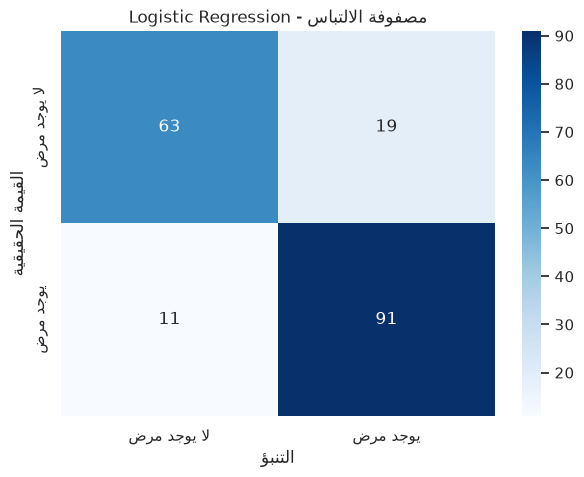

In [155]:
# حساب مصفوفة الالتباس
cm = confusion_matrix(y_test, y_pred)

# إنشاء حجم الرسم
plt.figure(figsize=(7, 5))

# رسم مصفوفة الالتباس
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["لا يوجد مرض", "يوجد مرض"],
    yticklabels=["لا يوجد مرض", "يوجد مرض"]
)

# إضافة عنوان للرسم
plt.title("مصفوفة الالتباس - Logistic Regression")

# تسمية المحور الأفقي
plt.xlabel("التنبؤ")

# تسمية المحور الرأسي
plt.ylabel("القيمة الحقيقية")

# عرض الرسم
plt.show()

In [156]:
# إنشاء نموذج شجرة القرار مع المعالجة المسبقة
decision_tree_model = Pipeline(
    steps=[
        # تطبيق المعالجة المسبقة على البيانات
        ("preprocessor", preprocessor),
        
        # إنشاء نموذج شجرة القرار
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

# تدريب النموذج باستخدام بيانات التدريب
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','sex','dataset',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [157]:
# إجراء التنبؤات باستخدام نموذج شجرة القرار
y_pred_tree = decision_tree_model.predict(X_test)

# حساب احتمالية الإصابة بالمرض
y_probability_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# عرض أول عشر تنبؤات
print("أول 10 تنبؤات:")
print(y_pred_tree[:10])

# عرض أول عشر احتمالات
print("\nأول 10 احتمالات:")
print(y_probability_tree[:10])

أول 10 تنبؤات:
[0 1 1 1 0 1 0 1 0 1]

أول 10 احتمالات:
[0. 1. 1. 1. 0. 1. 0. 1. 0. 1.]


In [158]:
# حساب مقاييس تقييم نموذج شجرة القرار
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_probability_tree)

# عرض نتائج التقييم
print("نتائج تقييم Decision Tree")
print("-" * 40)
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1-Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_tree:.4f}")

نتائج تقييم Decision Tree
----------------------------------------
Accuracy : 0.7663
Precision: 0.7706
Recall   : 0.8235
F1-Score : 0.7962
ROC-AUC  : 0.7593


In [159]:
# إنشاء نموذج Random Forest مع المعالجة المسبقة
random_forest_model = Pipeline(
    steps=[
        # تطبيق المعالجة المسبقة على البيانات
        ("preprocessor", preprocessor),
        
        # إنشاء نموذج الغابة العشوائية
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# تدريب النموذج باستخدام بيانات التدريب
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','sex','dataset',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [160]:
# إجراء التنبؤات باستخدام نموذج Random Forest
y_pred_rf = random_forest_model.predict(X_test)

# حساب احتمالية الإصابة بالمرض
y_probability_rf = random_forest_model.predict_proba(X_test)[:, 1]

# عرض أول عشر تنبؤات
print("أول 10 تنبؤات:")
print(y_pred_rf[:10])

# عرض أول عشر احتمالات للإصابة بالمرض
print("\nأول 10 احتمالات:")
print(y_probability_rf[:10])

أول 10 تنبؤات:
[0 1 1 1 1 1 0 1 0 1]

أول 10 احتمالات:
[0.435 0.91  0.805 0.995 0.745 0.71  0.235 0.965 0.015 0.78 ]


In [161]:
# حساب مقاييس تقييم نموذج Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_probability_rf)

# عرض نتائج التقييم
print("نتائج تقييم Random Forest")
print("-" * 40)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

نتائج تقييم Random Forest
----------------------------------------
Accuracy : 0.8478
Precision: 0.8558
Recall   : 0.8725
F1-Score : 0.8641
ROC-AUC  : 0.9314


In [162]:
# إنشاء نموذج K-Nearest Neighbors مع المعالجة المسبقة
knn_model = Pipeline(
    steps=[
        # تطبيق المعالجة المسبقة على البيانات
        ("preprocessor", preprocessor),
        
        # إنشاء نموذج KNN
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)

# تدريب النموذج باستخدام بيانات التدريب
knn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','sex','dataset',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [163]:
# إجراء التنبؤات باستخدام نموذج KNN
y_pred_knn = knn_model.predict(X_test)

# حساب احتمالية الإصابة بالمرض
y_probability_knn = knn_model.predict_proba(X_test)[:, 1]

# عرض أول عشر تنبؤات
print("أول 10 تنبؤات:")
print(y_pred_knn[:10])

# عرض أول عشر احتمالات للإصابة بالمرض
print("\nأول 10 احتمالات:")
print(y_probability_knn[:10])

أول 10 تنبؤات:
[1 1 1 1 1 1 1 1 0 1]

أول 10 احتمالات:
[0.6 1.  1.  1.  0.8 0.8 0.6 1.  0.  0.8]


In [164]:
# حساب مقاييس تقييم نموذج KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_probability_knn)

# عرض نتائج التقييم
print("نتائج تقييم KNN")
print("-" * 40)
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")

نتائج تقييم KNN
----------------------------------------
Accuracy : 0.8370
Precision: 0.8273
Recall   : 0.8922
F1-Score : 0.8585
ROC-AUC  : 0.8887


In [165]:
# إنشاء نموذج SVM مع المعالجة المسبقة
svm_model = Pipeline(
    steps=[
        # تطبيق المعالجة المسبقة على البيانات
        ("preprocessor", preprocessor),
        
        # إنشاء نموذج SVM
        ("classifier", SVC(
            probability=True,
            random_state=42
        ))
    ]
)

# تدريب النموذج باستخدام بيانات التدريب
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','sex','dataset',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [166]:
# إجراء التنبؤات باستخدام نموذج SVM
y_pred_svm = svm_model.predict(X_test)

# حساب احتمالية الإصابة بالمرض
y_probability_svm = svm_model.predict_proba(X_test)[:, 1]

# عرض أول عشر تنبؤات
print("أول 10 تنبؤات:")
print(y_pred_svm[:10])

# عرض أول عشر احتمالات للإصابة بالمرض
print("\nأول 10 احتمالات:")
print(y_probability_svm[:10])

أول 10 تنبؤات:
[0 1 1 1 1 1 0 1 0 1]

أول 10 احتمالات:
[0.17187803 0.89453302 0.87567371 0.93310593 0.7519549  0.8163036
 0.41445292 0.97580341 0.04040242 0.79797929]


In [167]:
# حساب مقاييس تقييم نموذج SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_probability_svm)

# عرض نتائج التقييم
print("نتائج تقييم SVM")
print("-" * 40)
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

نتائج تقييم SVM
----------------------------------------
Accuracy : 0.8641
Precision: 0.8348
Recall   : 0.9412
F1-Score : 0.8848
ROC-AUC  : 0.9218


In [168]:
# إنشاء جدول يحتوي على نتائج جميع النماذج
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf,
        accuracy_knn,
        accuracy_svm
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf,
        precision_knn,
        precision_svm
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf,
        recall_knn,
        recall_svm
    ],
    "F1-Score": [
        f1,
        f1_tree,
        f1_rf,
        f1_knn,
        f1_svm
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_knn,
        roc_auc_svm
    ]
})

# ترتيب النماذج حسب قيمة ROC-AUC من الأعلى إلى الأقل
model_results = model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

# عرض نتائج مقارنة النماذج
model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.847826,0.855769,0.872549,0.864078,0.931432
1,SVM,0.864130,0.834783,0.941176,0.884793,0.921808
2,Logistic Regression,0.836957,0.827273,0.892157,0.858491,0.920373
3,KNN,0.836957,0.827273,0.892157,0.858491,0.888749
4,Decision Tree,0.766304,0.770642,0.823529,0.796209,0.759326


<Figure size 1200x600 with 0 Axes>

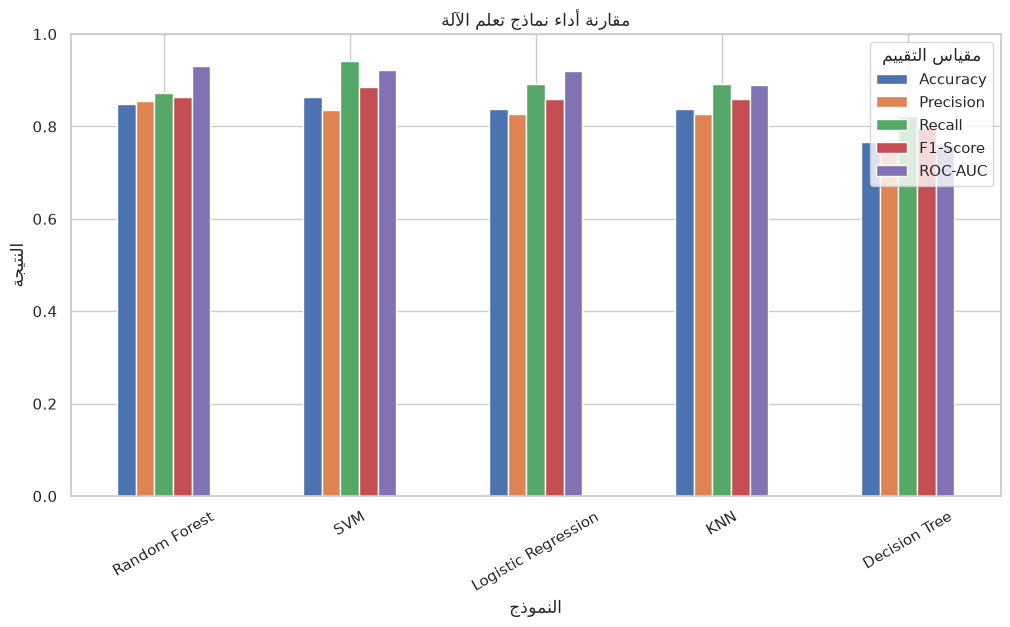

In [169]:
# تحويل جدول النتائج إلى صيغة مناسبة للرسم
results_for_plot = model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

# إنشاء رسم لمقارنة أداء النماذج
plt.figure(figsize=(12, 6))

# رسم نتائج المقارنة
results_for_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

# إضافة عنوان للرسم
plt.title("مقارنة أداء نماذج تعلم الآلة")

# تسمية المحور الأفقي
plt.xlabel("النموذج")

# تسمية المحور الرأسي
plt.ylabel("النتيجة")

# تحديد نطاق المحور الرأسي
plt.ylim(0, 1)

# تدوير أسماء النماذج
plt.xticks(rotation=30)

# عرض الرسم
plt.legend(title="مقياس التقييم")

# عرض الرسم
plt.show()

In [170]:
# الحصول على اسم النموذج صاحب أعلى قيمة ROC-AUC
best_model_name = model_results.loc[0, "Model"]

# الحصول على أعلى قيمة ROC-AUC
best_roc_auc = model_results.loc[0, "ROC-AUC"]

# عرض أفضل نموذج ونتيجته
print(f"أفضل نموذج حسب ROC-AUC: {best_model_name}")
print(f"قيمة ROC-AUC: {best_roc_auc:.4f}")

أفضل نموذج حسب ROC-AUC: Random Forest
قيمة ROC-AUC: 0.9314


In [171]:
# استيراد أداة البحث عن أفضل إعدادات للنموذج
from sklearn.model_selection import GridSearchCV

# تحديد مجموعة من الإعدادات المختلفة لنموذج Random Forest
# الهدف هو البحث عن أفضل مجموعة إعدادات تحقق أفضل أداء للنموذج.
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [172]:
# إنشاء GridSearchCV لاختبار جميع تركيبات الإعدادات المحددة
# يتم استخدام ROC-AUC كمعيار لاختيار أفضل نموذج.
grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# تدريب جميع النماذج واختيار أفضل إعدادات
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged

In [173]:
# عرض أفضل إعدادات وجدها البحث
print("أفضل إعدادات للنموذج:")
print(grid_search.best_params_)

# عرض أفضل قيمة ROC-AUC حصل عليها النموذج أثناء عملية البحث
print("\nأفضل ROC-AUC:")
print(f"{grid_search.best_score_:.4f}")

أفضل إعدادات للنموذج:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

أفضل ROC-AUC:
0.8881


In [174]:
# الحصول على أفضل نموذج تم العثور عليه أثناء عملية البحث
best_rf_model = grid_search.best_estimator_

# إجراء التنبؤات باستخدام النموذج المحسّن
y_pred_best_rf = best_rf_model.predict(X_test)

# حساب احتمالية الإصابة بالمرض
y_probability_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

# حساب مقاييس تقييم النموذج المحسّن
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)
roc_auc_best_rf = roc_auc_score(y_test, y_probability_best_rf)

# عرض نتائج تقييم النموذج المحسّن
print("نتائج تقييم Random Forest المحسّن")
print("-" * 45)
print(f"Accuracy : {accuracy_best_rf:.4f}")
print(f"Precision: {precision_best_rf:.4f}")
print(f"Recall   : {recall_best_rf:.4f}")
print(f"F1-Score : {f1_best_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_best_rf:.4f}")

نتائج تقييم Random Forest المحسّن
---------------------------------------------
Accuracy : 0.8424
Precision: 0.8476
Recall   : 0.8725
F1-Score : 0.8599
ROC-AUC  : 0.9319


In [175]:
# إنشاء تقرير شامل لأداء النموذج المحسّن
classification_report_best_rf = classification_report(
    y_test,
    y_pred_best_rf,
    target_names=["لا يوجد مرض", "يوجد مرض"]
)

# عرض تقرير التصنيف
print(classification_report_best_rf)

              precision    recall  f1-score   support

 لا يوجد مرض       0.84      0.80      0.82        82
    يوجد مرض       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



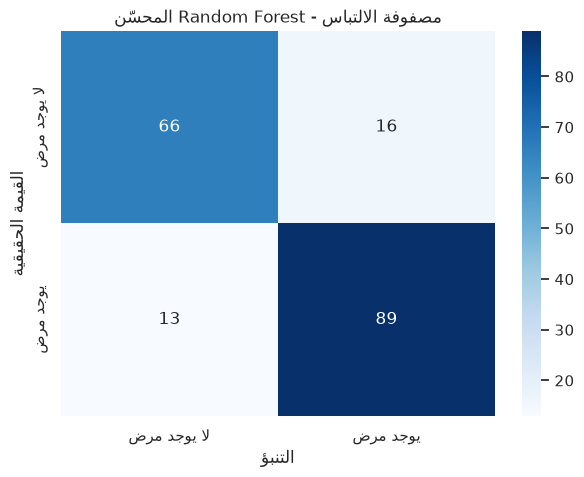

In [176]:
# حساب مصفوفة الالتباس للنموذج المحسّن
cm_best_rf = confusion_matrix(
    y_test,
    y_pred_best_rf
)

# إنشاء الرسم
plt.figure(figsize=(7, 5))

# رسم مصفوفة الالتباس
sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["لا يوجد مرض", "يوجد مرض"],
    yticklabels=["لا يوجد مرض", "يوجد مرض"]
)

# إضافة عنوان للرسم
plt.title("مصفوفة الالتباس - Random Forest المحسّن")

# تسمية المحور الأفقي
plt.xlabel("التنبؤ")

# تسمية المحور الرأسي
plt.ylabel("القيمة الحقيقية")

# عرض الرسم
plt.show()

In [177]:
# إنشاء جدول لمقارنة Random Forest الأصلي مع النموذج المحسّن
rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest المحسّن"
    ],
    "Accuracy": [
        accuracy_rf,
        accuracy_best_rf
    ],
    "Precision": [
        precision_rf,
        precision_best_rf
    ],
    "Recall": [
        recall_rf,
        recall_best_rf
    ],
    "F1-Score": [
        f1_rf,
        f1_best_rf
    ],
    "ROC-AUC": [
        roc_auc_rf,
        roc_auc_best_rf
    ]
})

# عرض جدول المقارنة
rf_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.847826,0.855769,0.872549,0.864078,0.931432
1,Random Forest المحسّن,0.842391,0.847619,0.872549,0.859903,0.931851


In [180]:
# الحصول على مرحلة المعالجة المسبقة من النموذج النهائي
best_preprocessor = best_rf_model.named_steps["preprocessor"]

# الحصول على نموذج Random Forest من الـ Pipeline
best_classifier = best_rf_model.named_steps["classifier"]

# الحصول على أسماء المتغيرات بعد المعالجة
feature_names = best_preprocessor.get_feature_names_out()

# الحصول على أهمية كل متغير من نموذج Random Forest
feature_importance = best_classifier.feature_importances_

# إنشاء جدول يحتوي على أسماء المتغيرات وأهميتها
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# ترتيب المتغيرات من الأكثر أهمية إلى الأقل أهمية
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# عرض أهم 15 متغيرًا
feature_importance_df.head(15)

,Feature,Importance
0,categorical__cp_asymptomatic,0.119334
1,numerical__chol,0.095640
2,numerical__oldpeak,0.091575
3,numerical__thalch,0.086287
4,numerical__age,0.084350
5,categorical__exang_True,0.072936
6,categorical__exang_False,0.060093
7,numerical__trestbps,0.048479
8,categorical__cp_atypical angina,0.045970
9,categorical__dataset_Switzerland,0.034193


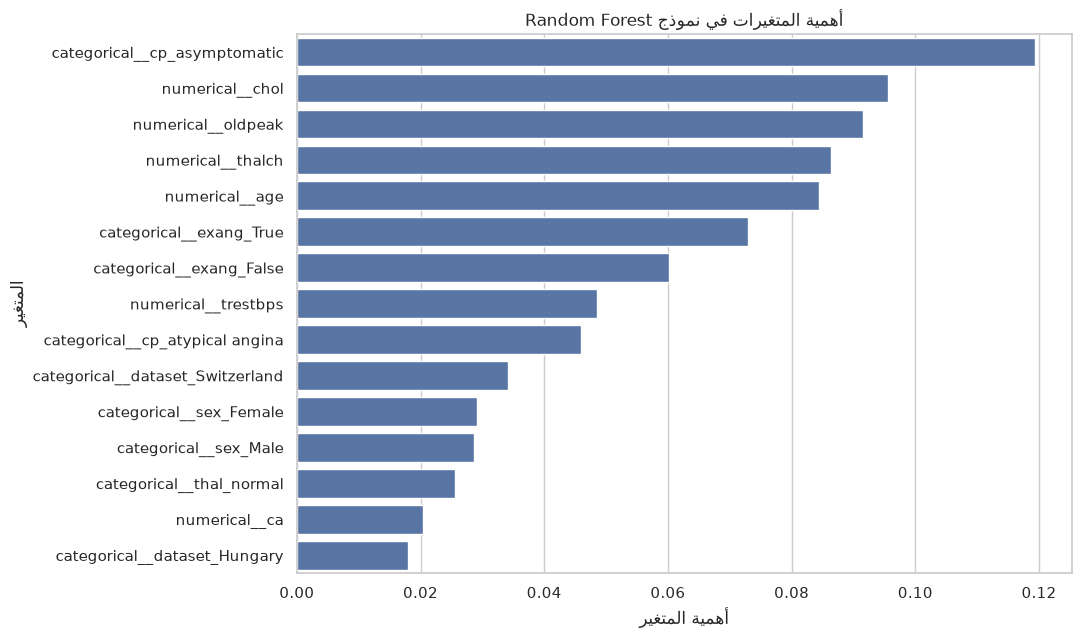

In [179]:
# اختيار أهم 15 متغيرًا للرسم
top_features = feature_importance_df.head(15)

# إنشاء الرسم
plt.figure(figsize=(10, 7))

# رسم أهمية المتغيرات
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

# إضافة عنوان للرسم
plt.title("أهمية المتغيرات في نموذج Random Forest")

# تسمية المحور الأفقي
plt.xlabel("أهمية المتغير")

# تسمية المحور الرأسي
plt.ylabel("المتغير")

# عرض الرسم
plt.show()

In [181]:
# استيراد مكتبة joblib لحفظ نموذج تعلم الآلة
import joblib

# تحديد مسار حفظ النموذج
model_path = "heart_disease_model.pkl"

# حفظ النموذج النهائي مع جميع مراحل المعالجة
joblib.dump(best_rf_model, model_path)

# التأكد من حفظ النموذج
print(f"تم حفظ النموذج بنجاح في: {model_path}")

تم حفظ النموذج بنجاح في: heart_disease_model.pkl


In [182]:
# تحميل النموذج المحفوظ من الملف
loaded_model = joblib.load(model_path)

# التأكد من تحميل النموذج بنجاح
print("تم تحميل النموذج بنجاح.")

تم تحميل النموذج بنجاح.


In [183]:
# استخدام النموذج المحفوظ لإجراء التنبؤات
loaded_predictions = loaded_model.predict(X_test)

# التحقق من أن التنبؤات بعد تحميل النموذج مطابقة للتنبؤات السابقة
predictions_match = np.array_equal(
    y_pred_best_rf,
    loaded_predictions
)

# عرض نتيجة الاختبار
print("هل التنبؤات متطابقة؟", predictions_match)

هل التنبؤات متطابقة؟ True


In [184]:
# إنشاء دالة للتنبؤ بحالة مريض جديد
def predict_heart_disease(patient_data):
    
    # تحويل بيانات المريض إلى DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # الحصول على التنبؤ من النموذج
    prediction = loaded_model.predict(patient_df)[0]
    
    # الحصول على احتمالية الإصابة بالمرض
    probability = loaded_model.predict_proba(patient_df)[0][1]
    
    # تحديد مستوى الخطورة بناءً على احتمالية الإصابة
    if probability < 0.30:
        risk_level = "منخفض"
    elif probability < 0.70:
        risk_level = "متوسط"
    else:
        risk_level = "مرتفع"
    
    # تحديد نتيجة التنبؤ
    diagnosis = "يوجد احتمال للإصابة بمرض القلب" if prediction == 1 else "لا يوجد احتمال مرتفع للإصابة بمرض القلب"
    
    # إرجاع نتائج التنبؤ
    return {
        "prediction": int(prediction),
        "probability": round(float(probability), 4),
        "risk_level": risk_level,
        "diagnosis": diagnosis
    }

In [185]:
# اختيار أول مريض من بيانات الاختبار لتجربة نظام التنبؤ
sample_patient = X_test.iloc[0].to_dict()

# استخدام الدالة للتنبؤ بحالة المريض
prediction_result = predict_heart_disease(sample_patient)

# عرض نتيجة التنبؤ
prediction_result

{'prediction': 0,
 'probability': 0.3664,
 'risk_level': 'متوسط',
 'diagnosis': 'لا يوجد احتمال مرتفع للإصابة بمرض القلب'}

In [186]:
# عرض بيانات المريض المستخدمة في عملية التنبؤ
print("بيانات المريض:")
print(sample_patient)

# عرض نتيجة التنبؤ
print("\nنتيجة التنبؤ:")
print(f"التشخيص المبدئي: {prediction_result['diagnosis']}")
print(f"احتمالية الإصابة: {prediction_result['probability'] * 100:.2f}%")
print(f"مستوى الخطورة: {prediction_result['risk_level']}")

بيانات المريض:
{'age': 49, 'sex': 'Male', 'dataset': 'Hungary', 'cp': 'asymptomatic', 'trestbps': 130.0, 'chol': 206.0, 'fbs': False, 'restecg': 'normal', 'thalch': 170.0, 'exang': False, 'oldpeak': 0.0, 'slope': 'flat', 'ca': 0.0, 'thal': 'normal'}

نتيجة التنبؤ:
التشخيص المبدئي: لا يوجد احتمال مرتفع للإصابة بمرض القلب
احتمالية الإصابة: 36.64%
مستوى الخطورة: متوسط
